In [14]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
from shapely.geometry import Point
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, mean_squared_error



In [15]:
# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

data_dir = Path("/Users/alexrabeau/Desktop/SPHERE/NBN-LPI-forecasting/data/NBN-atlas/species/")

euplagia_quadripunctaria = pd.read_csv(data_dir / "Euplagia_quadripunctaria/euplagia_quadripunctaria_processed.csv")
fratercula_arctica = pd.read_csv(data_dir / "Fratercula_arctica/fratercula_arctica_processed.csv")
haliaeetus_albicilla = pd.read_csv(data_dir / "Haliaeetus_albicilla/haliaeetus_albicilla_processed.csv")
lutra_lutra = pd.read_csv(data_dir / "Lutra_lutra/lutra_lutra_processed.csv")
pandion_haliaetus = pd.read_csv(data_dir / "Pandion_haliaetus/pandion_haliaetus_processed.csv")
pipistrellus_pipistrellus = pd.read_csv(data_dir / "Pipistrellus_pipistrellus/pipistrellus_pipistrellus_processed.csv")
sciurus_vulgaris = pd.read_csv(data_dir / "Sciurus_vulgaris/sciurus_vulgaris_processed.csv")
triturus_cristatus = pd.read_csv(data_dir / "Triturus_cristatus/triturus_cristatus_processed.csv")
vipera_berus = pd.read_csv(data_dir / "Vipera_berus/vipera_berus_processed.csv")


<ipython-input-17-fdb19d6a36bf>:17: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


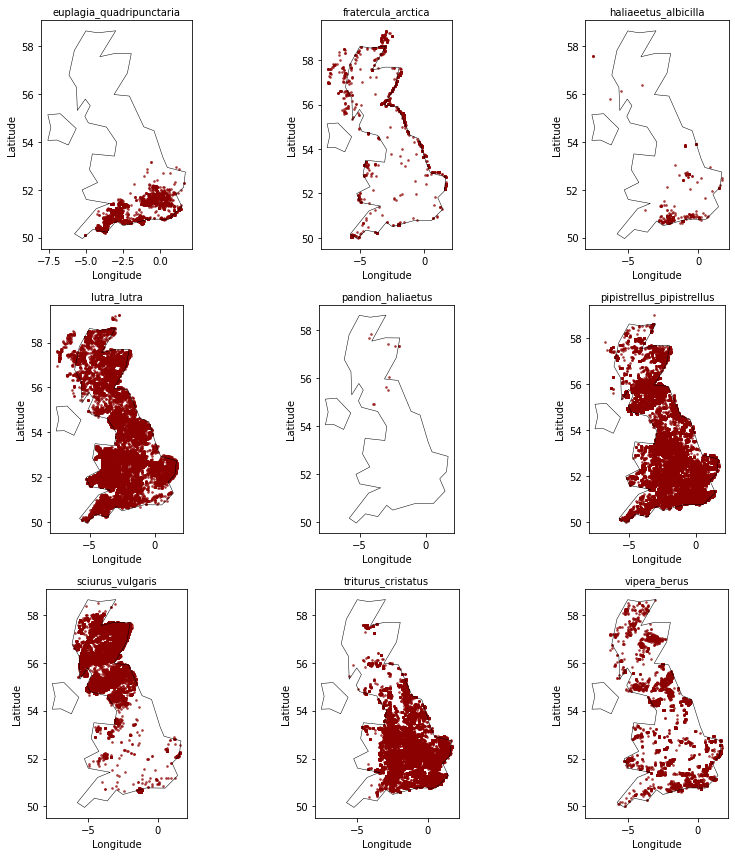

In [17]:
# ---------------------------------------------------------
# Explore data: Occurrence maps
# ---------------------------------------------------------

species_dfs = {
    'euplagia_quadripunctaria': euplagia_quadripunctaria,
    'fratercula_arctica': fratercula_arctica,
    'haliaeetus_albicilla': haliaeetus_albicilla,
    'lutra_lutra': lutra_lutra,
    'pandion_haliaetus': pandion_haliaetus,
    'pipistrellus_pipistrellus': pipistrellus_pipistrellus,
    'sciurus_vulgaris': sciurus_vulgaris,
    'triturus_cristatus': triturus_cristatus,
    'vipera_berus': vipera_berus
    }

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
uk = world[world['name'] == 'United Kingdom']

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, (species, df) in zip(axes, species_dfs.items()):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['Longitude..WGS84.'], df['Latitude..WGS84.']),
        crs='EPSG:4326'
    )
    uk.boundary.plot(ax=ax, color='black', linewidth=0.5)
    gdf.plot(ax=ax, markersize=3, alpha=0.6, color='darkred')
    ax.set_title(species, fontsize=10)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

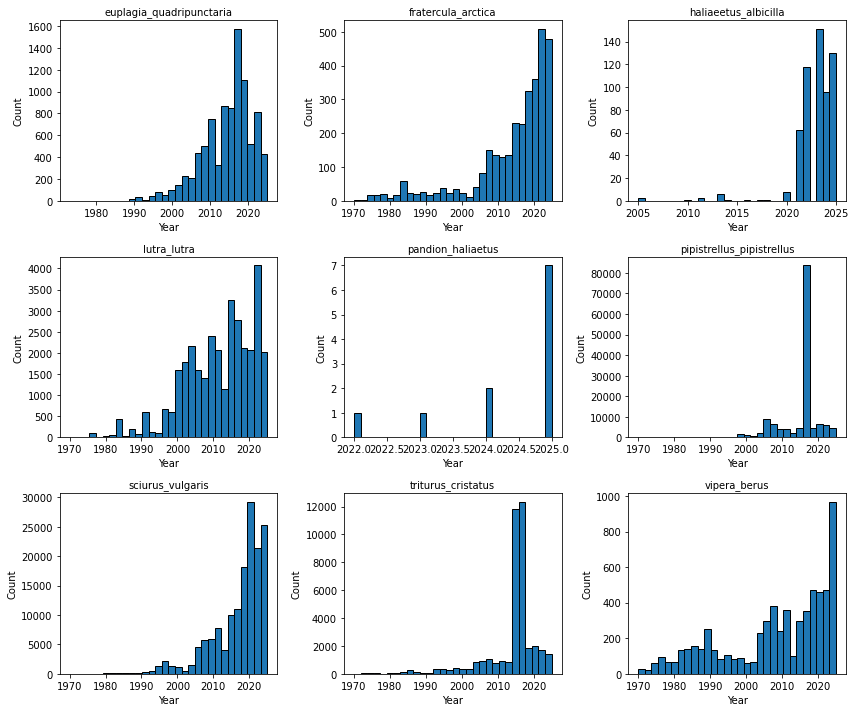

In [18]:
# ---------------------------------------------------------
# Explore data: Year histograms
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for ax, (species, df) in zip(axes, species_dfs.items()):
    ax.hist(df['Year'].dropna(), bins=30, edgecolor='black')
    ax.set_title(species, fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [41]:
# ---------------------------------------------------------
# Set parameters
# ---------------------------------------------------------

SPECIES = 'euplagia_quadripunctaria'

TARGET_REGION = "East"

TRAIN_START = 1970
TRAIN_END = 2022
VALIDATION_START = 2023
VALIDATION_END = 2025

ABSENCE_RATIO = 3
RANDOM_SEED = 42

GRID_DIR = Path("/Users/alexrabeau/Desktop/SPHERE/NBN-LPI-forecasting/data/env_predictors/gridded/")
OUTPUT_DIR = Path("/Users/alexrabeau/Desktop/SPHERE/NBN-LPI-forecasting/submission/")



In [27]:
# ---------------------------------------------------------
# Prepare occurrences
# ---------------------------------------------------------

occ = species_dfs[SPECIES].copy()
print("Occurrences:", occ.shape)

occ["Event.Date"] = pd.to_datetime(
    occ["Event.Date"],
    errors="coerce"
)

Occurrences: (9124, 57)


In [33]:
# ---------------------------------------------------------
# Define Environmental Predictors
# ---------------------------------------------------------

NON_PREDICTORS = {
    "Occurrence.ID",
    "Scientific.name",
    "Event.Date",
    "Day",
    "Month",
    "Year",
    "Latitude..WGS84.",
    "Longitude..WGS84.",
    "grid_id",
    "Region"
}

predictors = [
    c for c in occ.columns
    if (
        c not in NON_PREDICTORS
        and c in occ.columns
        and pd.api.types.is_numeric_dtype(occ[c])
    )
]

print("Number of predictors:", len(predictors))


Number of predictors: 47


In [65]:
# ---------------------------------------------------------
# Create Presence data
# ---------------------------------------------------------

def get_presence_data(
    occurrences,
    year
):

    if len(occurrences) == 0:
        return None

    columns = [
        "grid_id",
        "Region",
        "Longitude..WGS84.",
        "Latitude..WGS84."
    ] + predictors

    presence_data = occurrences[
        columns
    ].copy()

    presence_data["presence"] = 1
    presence_data["year"] = year

    return presence_data

In [59]:
# ---------------------------------------------------------
# Generate Pseudo-absences
# ---------------------------------------------------------

def generate_pseudo_absences(grid, presence_grid_ids, n_absences, rng):

    # Remove cells containing known presences
    available = grid[
        ~grid["grid_id"].isin(
            presence_grid_ids
        )
    ].copy()

    if len(available) < n_absences:

        raise ValueError(
            "Not enough available grid cells "
            "to generate pseudo-absences."
        )

    sampled = available.sample(
        n=n_absences,
        random_state=rng
    ).copy()

    sampled["presence"] = 0

    return sampled


In [90]:
# ---------------------------------------------------------
# Subset to annual datasets
# ---------------------------------------------------------
def create_year_dataset(
    year,
    occurrences,
    n_pa_per_presence,
    rng
):


    # Load grid
    file = os.path.join(GRID_DIR,f"gridden_env_{year}.csv")
    grid = pd.read_csv(file)


    # Presence data
    presence_data = get_presence_data(
        occurrences=occurrences,
        year=year
    )

    if presence_data is None:
        print(
            f"  {year}: no presences"
        )
        return None


    # Generate pseudo-absences
    presence_grid_ids = (
        presence_data["grid_id"]
        .dropna()
        .unique()
    )

    n_presences = len(
        presence_grid_ids
    )

    n_absences = (
        n_presences
        * ABSENCE_RATIO
    )

    absence_data = generate_pseudo_absences(
        grid=grid,
        presence_grid_ids=presence_grid_ids,
        n_absences=n_absences,
        rng=rng
    )
    absence_data["year"] = year


    # Combine datasets
    columns = [
        "grid_id",
        "Region",
        "Longitude..WGS84.",
        "Latitude..WGS84."
    ] + predictors + [
        "presence",
        "year"
    ]

    presence_data = presence_data[
        columns
    ]

    absence_data = absence_data[
        columns
    ]

    result = pd.concat(
        [
            presence_data,
            absence_data
        ],
        ignore_index=True
    )

    return result

In [94]:
# 4. MODEL TRAINING
# ---------------------------------------------------------
# i. Training dataset: 1970–2022 - all UK regions except 1 target region
# ---------------------------------------------------------

rng = np.random.RandomState(RANDOM_SEED)

print("\nBuilding training data...")


# Build training data
training_parts = []

for year in range(
    TRAIN_START,
    TRAIN_END + 1
):

    print(f"Processing training year {year}")


    # Training occurrences exclude the target region
    yearly_occurrences = occ[
        (occ["Year"] == year) 
        & 
        (occ["Region"]!= TARGET_REGION)
        ].copy()

    if len(yearly_occurrences) == 0:
        print(
            f"  No training occurrences in {year}"
        )

        continue


    # Build dataset
    yearly_data = create_year_dataset(
        year=year,
        occurrences=yearly_occurrences,
        n_pa_per_presence=(
            ABSENCE_RATIO
        ),
        rng=rng
    )

    if yearly_data is not None:
        training_parts.append(
            yearly_data
        )


# Combine years
train = pd.concat(
    training_parts,
    ignore_index=True
)

print("\nTraining dataset:", train.shape)
print("\nTraining class counts:")
print(train["presence"].value_counts())


# Create model
model = make_pipeline(

    SimpleImputer(
        strategy="median"
    ),

    HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=RANDOM_SEED
    )
)


# Fit model
X_train = train[predictors]

y_train = train["presence"]

model.fit(X_train, y_train)

print("Model fitted.")


Building training data...
Processing training year 1970
  No training occurrences in 1970
Processing training year 1971
  No training occurrences in 1971
Processing training year 1972
  No training occurrences in 1972
Processing training year 1973
Processing training year 1974
  No training occurrences in 1974
Processing training year 1975
Processing training year 1976
Processing training year 1977
Processing training year 1978
Processing training year 1979
Processing training year 1980
Processing training year 1981
  No training occurrences in 1981
Processing training year 1982
Processing training year 1983
Processing training year 1984
Processing training year 1985
  No training occurrences in 1985
Processing training year 1986
Processing training year 1987
Processing training year 1988
Processing training year 1989
Processing training year 1990
Processing training year 1991
Processing training year 1992
Processing training year 1993
Processing training year 1994
Processing training

In [99]:
# 4. MODEL VALIDATION
# ---------------------------------------------------------
# i. Validation dataset: 2023–2025 - target region
# ---------------------------------------------------------

# Build validation data
print(
    "\nBuilding validation data..."
)

validation_parts = []

for year in range(
    VALIDATION_START,
    VALIDATION_END + 1
):

    print(
        f"Processing validation year {year}"
    )


    # Validation occurrences are TARGET REGION ONLY
    yearly_occurrences = occ[
        (
            occ["Year"] == year
        )
        &
        (
            occ["Region"]
            == TARGET_REGION
        )
    ].copy()


    if len(yearly_occurrences) == 0:

        print(
            f"  No validation occurrences in {year}"
        )

        continue

    yearly_data = create_year_dataset(
        year=year,
        occurrences=yearly_occurrences,
        n_pa_per_presence=(
            ABSENCE_RATIO
        ),
        rng=rng
    )

    if yearly_data is not None:

        validation_parts.append(
            yearly_data
        )

validation = pd.concat(
    validation_parts,
    ignore_index=True
)

print(
    "\nValidation dataset:",
    validation.shape
)

print(
    "\nValidation class counts:"
)

print(
    validation["presence"].value_counts()
)


# Validate model
X_val = validation[
    predictors
]

y_val = validation[
    "presence"
]

val_probability = model.predict_proba(
    X_val
)[:, 1]

auc = roc_auc_score(
    y_val,
    val_probability
)

brier = mean_squared_error(
    y_val,
    val_probability
)

print(
    "\n============================="
)

print(
    "VALIDATION RESULTS"
)

print(
    "============================="
)

print(
    f"Species:       {SPECIES}"
)

print(
    f"Target region: {TARGET_REGION}"
)

print(
    f"Training:      {TRAIN_START}-{TRAIN_END}"
)

print(
    f"Validation:    {VALIDATION_START}-{VALIDATION_END}"
)

print(
    f"AUC:           {auc:.3f}"
)

print(
    f"Brier/MSE:     {brier:.3f}"
)


Building validation data...
Processing validation year 2023
Processing validation year 2024
Processing validation year 2025

Validation dataset: (155, 53)

Validation class counts:
presence
0    108
1     47
Name: count, dtype: int64

VALIDATION RESULTS
Species:       euplagia_quadripunctaria
Target region: East
Training:      1970-2022
Validation:    2023-2025
AUC:           0.879
Brier/MSE:     0.178


In [111]:
# ---------------------------------------------------------
# Export validation results
# ---------------------------------------------------------

validation_output = validation[
    [
        "year",
        "grid_id",
        "Region",
        "Longitude..WGS84.",
        "Latitude..WGS84.",
        "presence"
    ]
].copy()

validation_output[
    "prediction"
] = val_probability

validation_output.to_parquet(
    os.path.join(
        OUTPUT_DIR,
        "validation_predictions.csv"
    ),
    index=False
)